In [18]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, r2_score

#train_test_split - prevents overfitting 
#StandardScaler - ensures all features are on same scale
#LinearRegression - core model for prediction
#RFE - automates feature selection
#mean_squared_error, r2_score - evaluate model performance

In [19]:
# Load the dataset
df = pd.read_csv("D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\ML-Linear Regression-8\\Housing.csv")

In [20]:
# Data Cleaning and Preparation
# Convert categorical variables to lowercase for consistency
df = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12680\2626552458.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [21]:
# Convert binary categorical variables to 0/1
binary_vars = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[binary_vars] = df[binary_vars].applymap(lambda x: 1 if x == 'yes' else 0)

#why to convert? - Linear Regression requires numcercal input 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12680\546264814.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_vars] = df[binary_vars].applymap(lambda x: 1 if x == 'yes' else 0)


In [22]:
# Dummy encoding for 'furnishingstatus'
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

#one-hot encoding 
#HW/assignment - furnishingstatus has values - furnished, semi-furnished, unfurnished. The assignment is write on the document - 
#how the encoding happens - write in the tabular form
#drop_first = True - avoid multicollineariy 
# assignment - research for get_dummies 

In [23]:
# Define features and target
X = df.drop('price', axis=1)
y = df['price']



In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Scaling
scaler = StandardScaler()
#standardizes feature to mean = 0 and STD DEVIATION =1
#prevents featrues like area (large values) from dominating others. 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Bottom-Up Model Building
# Start with one variable: 'area'
X_area = X_train_scaled[:, X.columns.get_loc('area')].reshape(-1, 1)
model_area = LinearRegression().fit(X_area, y_train)
print("R² with area only:", model_area.score(X_area, y_train))

# Add 'bathrooms'
X_area_bath = X_train_scaled[:, [X.columns.get_loc('area'), X.columns.get_loc('bathrooms')]]
model_area_bath = LinearRegression().fit(X_area_bath, y_train)
print("R² with area + bathrooms:", model_area_bath.score(X_area_bath, y_train))


#R^2 = 0.304 - area alone explains 30.4% of the variance in the target
#R^2 = 0.48, adding bathrooms - variance got boosted 48.9%
#bottom-up approach, start with simple, add features one by one, and observe how each improves model performance
#how it helps
# - identify strong predictors
# - avoid overfitting by exluding redundant features
#build strong model with fewer variables

R² with area only: 0.3040277372548503
R² with area + bathrooms: 0.48850782034936036


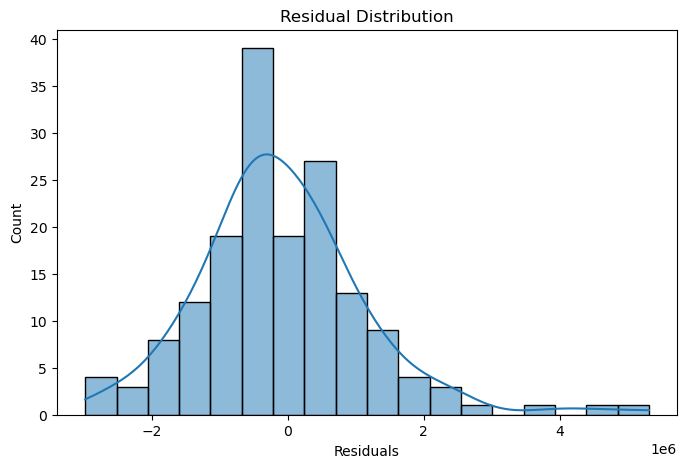

In [25]:
# Full Model
#trains the linear regression model using all features in X_train_scaled
#X_train_scaled is standard version of training features (mean=0, std=1) -
#y_train = target variable
full_model = LinearRegression().fit(X_train_scaled, y_train)
y_pred = full_model.predict(X_test_scaled)

# Residual Analysis
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

#residual analysis - to evaluate how well your regression model is performing on the test set
#heteroscedsticity - non constant variance - skewness indicate outliers


In [26]:
# Model Evaluation
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

#RMSE - show average prediction error
#R^2 - proportion of variance
#RMSE & R^2  - asses model accuracy
#RMSE - 12.3 Lakh on average
#R^2 64.6% - of the variation in house prices 
#  Feature Selection using RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

selected_features = X.columns[rfe.support_]
print("Top 5 features selected by RFE:", list(selected_features))



RMSE: 1234106.7496376848
R² Score: 0.6463350878895877
Top 5 features selected by RFE: ['area', 'bathrooms', 'stories', 'basement', 'airconditioning']


In [27]:
# Final Model with RFE-selected features
X_train_rfe = X_train_scaled[:, rfe.support_]
X_test_rfe = X_test_scaled[:, rfe.support_]

final_model = LinearRegression().fit(X_train_rfe, y_train)
y_pred_rfe = final_model.predict(X_test_rfe)

print("R² Score with RFE-selected features:", r2_score(y_test, y_pred_rfe))

#57% of the variation in house prices on the test set
#compare to the full model (R^2 = 0.646) ...slight drop in the performance but what we addressed
# reduced the risk of overfitting
# we came to know which featrues are most predictive

#full model has highet R^2 but it many include redundant features (noise)
#RFE model is more robust - especially if deployed to PRODUCTION env


R² Score with RFE-selected features: 0.5697806958575284
